# This project aims to develop a machine learning model that predicts lithology (either reservoir rock or non-reservoir rock) from well logs using Gamma ray logs, DPHI porosity, Neutron porosity, caliper logs, and Deep Induction log

### Real well log data was obtained from Kansas field and available at https://kgsimages.blob.core.windows.net/web/web_1/WebDocs/WellLogs/kcc_logs_2025/1056890332.las

In [51]:
# Install the needed libraries
import lasio
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

### 1. Read the well log data from the webpage and clean it up by dropping nulls

In [84]:
las = lasio.read('https://kgsimages.blob.core.windows.net/web/web_1/WebDocs/WellLogs/kcc_logs_2025/1056890332.las')
df = las.df()
df.head()

,GR,CALY,CALM,CALX,SP,TENS,BS,SFL,ILD,ILM,DPHI,NPHI,PE,MINV,MNOR,DRHO,DT,SPHI
DEPT,,,,,,,,,,,,,,,,,,
244.0,69.678,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
244.5,71.686,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
245.0,75.918,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
245.5,80.436,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
246.0,76.796,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [52]:
las = lasio.read('Log data Kansas.las')
df = las.df()
df.head()

,GR,CALY,CALM,CALX,SP,TENS,BS,SFL,ILD,ILM,DPHI,NPHI,PE,MINV,MNOR,DRHO,DT,SPHI
DEPT,,,,,,,,,,,,,,,,,,
244.0,69.678,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
244.5,71.686,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
245.0,75.918,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
245.5,80.436,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
246.0,76.796,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6073 entries, 244.0 to 3280.0
Data columns (total 18 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   GR      5941 non-null   float64
 1   CALY    5805 non-null   float64
 2   CALM    5810 non-null   float64
 3   CALX    5816 non-null   float64
 4   SP      5943 non-null   float64
 5   TENS    5942 non-null   float64
 6   BS      5918 non-null   float64
 7   SFL     5938 non-null   float64
 8   ILD     5944 non-null   float64
 9   ILM     5916 non-null   float64
 10  DPHI    5950 non-null   float64
 11  NPHI    5818 non-null   float64
 12  PE      5948 non-null   float64
 13  MINV    5936 non-null   float64
 14  MNOR    5936 non-null   float64
 15  DRHO    5946 non-null   float64
 16  DT      5946 non-null   float64
 17  SPHI    5946 non-null   float64
dtypes: float64(18)
memory usage: 901.5 KB


In [54]:
# the nulls will be dropped and not interpolated
df = df.dropna()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5750 entries, 339.5 to 3214.0
Data columns (total 18 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   GR      5750 non-null   float64
 1   CALY    5750 non-null   float64
 2   CALM    5750 non-null   float64
 3   CALX    5750 non-null   float64
 4   SP      5750 non-null   float64
 5   TENS    5750 non-null   float64
 6   BS      5750 non-null   float64
 7   SFL     5750 non-null   float64
 8   ILD     5750 non-null   float64
 9   ILM     5750 non-null   float64
 10  DPHI    5750 non-null   float64
 11  NPHI    5750 non-null   float64
 12  PE      5750 non-null   float64
 13  MINV    5750 non-null   float64
 14  MNOR    5750 non-null   float64
 15  DRHO    5750 non-null   float64
 16  DT      5750 non-null   float64
 17  SPHI    5750 non-null   float64
dtypes: float64(18)
memory usage: 853.5 KB


In [55]:
df.head()

,GR,CALY,CALM,CALX,SP,TENS,BS,SFL,ILD,ILM,DPHI,NPHI,PE,MINV,MNOR,DRHO,DT,SPHI
DEPT,,,,,,,,,,,,,,,,,,
339.5,97.759,8.915,8.112,9.482,33.252,1792.279,7.873,30.719,24.408,25.642,19.270,29.258,2.559,11.374,14.021,0.015,119.483,29.946
340.0,107.505,8.943,8.186,9.527,33.485,1813.362,7.873,28.734,22.865,23.331,18.986,29.006,2.781,11.244,12.614,0.002,121.717,29.946
340.5,115.464,8.938,8.220,9.536,34.530,1825.388,7.873,28.568,21.419,21.320,19.554,29.977,2.746,11.118,12.459,-0.008,124.449,29.947
341.0,119.610,8.929,8.226,9.574,35.577,1829.193,7.873,27.998,20.066,19.482,19.866,29.971,2.701,10.818,12.199,-0.011,128.074,29.947
341.5,127.681,8.920,8.231,9.633,36.481,1832.998,7.873,25.849,18.798,17.801,20.276,29.965,2.655,9.918,11.179,-0.010,130.821,29.947


## 2. Create the dependent variable (lithology) from gamma ray values

In [56]:
df['Lithology'] = np.where (df['GR'] < 75, 0, 1)
df['Lithology'].head()

DEPT
339.5    1
340.0    1
340.5    1
341.0    1
341.5    1
Name: Lithology, dtype: int32

In [57]:
y = df['Lithology']

## 3. List and create the independent variable for the model

In [58]:
df.columns

Index(['GR', 'CALY', 'CALM', 'CALX', 'SP', 'TENS', 'BS', 'SFL', 'ILD', 'ILM',
       'DPHI', 'NPHI', 'PE', 'MINV', 'MNOR', 'DRHO', 'DT', 'SPHI',
       'Lithology'],
      dtype='object')

In [59]:
Features = ['GR', 'CALX', 'ILD', 'DPHI', 'NPHI']
X = df[Features]

### 3a. Check for collinearity between the independent variavles before proceeding

,GR,CALX,ILD,DPHI,NPHI
GR,1.000000,0.406116,-0.505212,0.446537,0.701930
CALX,0.406116,1.000000,-0.391660,0.567353,0.506967
ILD,-0.505212,-0.391660,1.000000,-0.484239,-0.633122
DPHI,0.446537,0.567353,-0.484239,1.000000,0.651580
NPHI,0.701930,0.506967,-0.633122,0.651580,1.000000


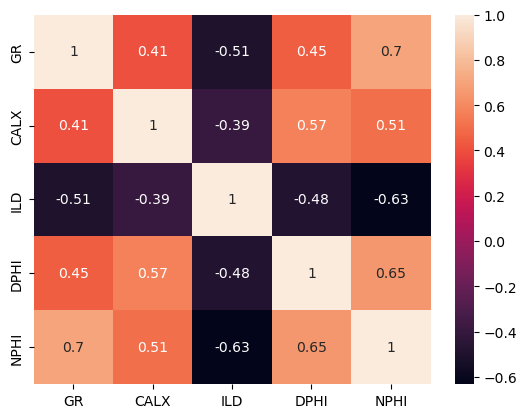

In [60]:
corrr = X.corr()
sns.heatmap(corrr, annot = True)
corrr

## 4. Data Splitting and model training

In [61]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 12)
model = RandomForestClassifier(n_estimators = 100)
model.fit(X_train, y_train)

RandomForestClassifier()

## 5. Use the model to predict and evaluate the pedictions

In [62]:
y_pred = model.predict(X_test)
print (classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       537
           1       1.00      1.00      1.00       613

    accuracy                           1.00      1150
   macro avg       1.00      1.00      1.00      1150
weighted avg       1.00      1.00      1.00      1150



## 6. Interpretation of model prediction result

## 7. Determining the importance of each feature in predicting lithology

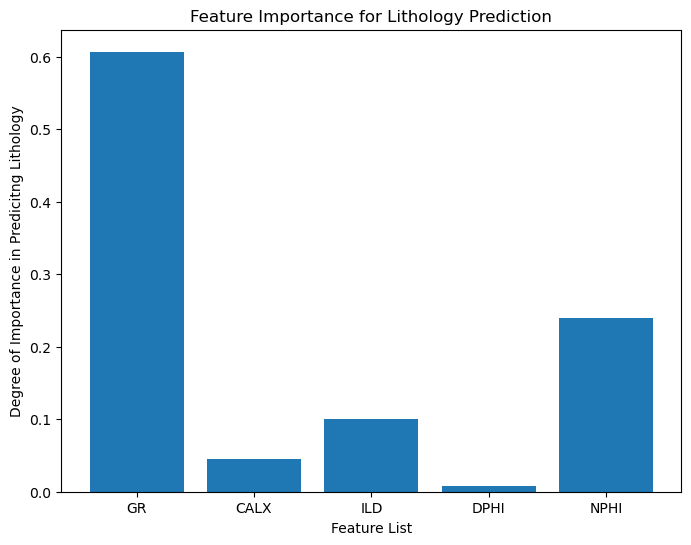

In [63]:
Importance = model.feature_importances_
plt.figure(figsize =(8,6))
plt.bar(Features, Importance)
plt.title("Feature Importance for Lithology Prediction")
plt.xlabel('Feature List')
plt.ylabel('Degree of Importance in Predicitng Lithology')
plt.show()

## 8. Plot the lithology for the entire logged interval using the developed model

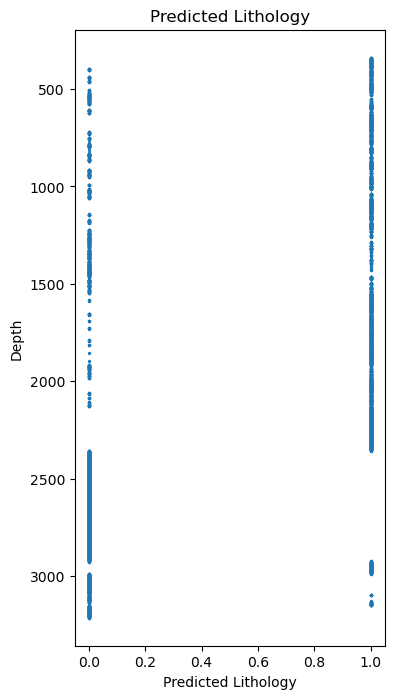

In [75]:
df['Predicted_lithology'] = model.predict(X)
plt.figure(figsize=(4,8))
plt.scatter(df['Predicted_lithology'], df.index, s=2)
plt.ylabel('Depth')
plt.xlabel('Predicted Lithology')
plt.key(
plt.gca().invert_yaxis()

plt.title("Predicted Lithology")

plt.show()


## 9. Interporetation and Conclusion